# Mental Health Detection — MentalRoBERTa Fine-Tune
### Depression, Anxiety & Suicidal Risk Detection from Text

**What this notebook does:**
1. Loads and deduplicates the Kaggle mental health dataset
2. Maps labels to 3 classes: Depression, Anxiety, Suicidal (separate — not merged)
3. Fine-tunes `mental/mental-roberta-base` — pre-trained on Reddit mental health posts
4. Three independent binary output heads (Depression / Anxiety / Suicidal)
5. Threshold calibration on the validation set (not hardcoded 0.5)
6. Full evaluation: Accuracy, F1, ROC-AUC, PR-AUC, Confusion Matrices
7. ONNX export + inference helper with hard-coded crisis override

**Dataset:** `suchintikasarkar/sentiment-analysis-for-mental-health`  
Add via **+ Add Data** → search `sentiment-analysis-for-mental-health`

**Before running:**
- Go to [huggingface.co/mental/mental-roberta-base](https://huggingface.co/mental/mental-roberta-base) and request access (approved instantly)
- Add your HuggingFace token: **Add-ons → Secrets → Add** → name it `HF_TOKEN`
- Enable GPU: **Settings → Accelerator → GPU T4 x2**

**Expected training time on T4:** ~15–20 minutes for 5 epochs


## Cell 1 — Install & Authenticate

In [2]:
# Install required packages
!pip install transformers==4.40.2 onnx onnxruntime onnxscript scikit-learn --quiet

# Authenticate with HuggingFace using Kaggle secret
# Before running: Add-ons → Secrets → Add → name: HF_TOKEN → paste your token
from kaggle_secrets import UserSecretsClient
import os

try:
    user_secrets = UserSecretsClient()
    hf_token = user_secrets.get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    from huggingface_hub import login
    login(token=hf_token, add_to_git_credential=False)
    print("✓ HuggingFace authentication successful.")
except Exception as e:
    print(f"✗ HuggingFace auth failed: {e}")
    print("  Make sure you added HF_TOKEN under Add-ons → Secrets")
    raise


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 3.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 75.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 71.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 92.0 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.2 which is incompatible.


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ HuggingFace authentication successful.


## Cell 2 — Import Libraries

In [3]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)

import onnx
import onnxruntime as ort

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device      : {DEVICE}")
print(f"PyTorch ver : {torch.__version__}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")


Device      : cuda
PyTorch ver : 2.10.0+cu128
GPU         : Tesla T4


## Cell 3 — Load Dataset

In [4]:
import os, glob

# Search for the CSV under all possible Kaggle input paths
candidates = glob.glob('/kaggle/input/**/Combined Data.csv', recursive=True)
if not candidates:
    raise FileNotFoundError(
        "Could not find 'Combined Data.csv'. "
        "Click '+ Add Data' and add 'sentiment-analysis-for-mental-health'."
    )
CSV_PATH = candidates[0]
print(f"Found dataset at: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

print(f"\nDataset shape : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print(f"\nRaw label distribution:")
print(df['status'].value_counts())


Found dataset at: /kaggle/input/datasets/suchintikasarkar/sentiment-analysis-for-mental-health/Combined Data.csv

Dataset shape : (53043, 2)
Columns       : ['statement', 'status']

Raw label distribution:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


## Cell 4 — Deduplicate & Map Labels

**Key fix vs original notebook:**
- `drop_duplicates` added before split — without this, the same Reddit post can appear
  in both train and test, inflating test metrics.
- `Suicidal` is kept as its **own class** — not merged into Depression.
  In a real product, suicidal ideation must be flagged independently.


Rows before dedup : 53,043
Rows after dedup  : 51,074
Duplicates removed: 1,969

Unique raw labels found:
['Anxiety' 'Normal' 'Depression' 'Suicidal' 'Stress' 'Bipolar'
 'Personality disorder']

Final label distribution:
label
Depression    17588
Normal        16039
Suicidal      10641
Anxiety        6806
Name: count, dtype: int64

Total usable samples: 51,074


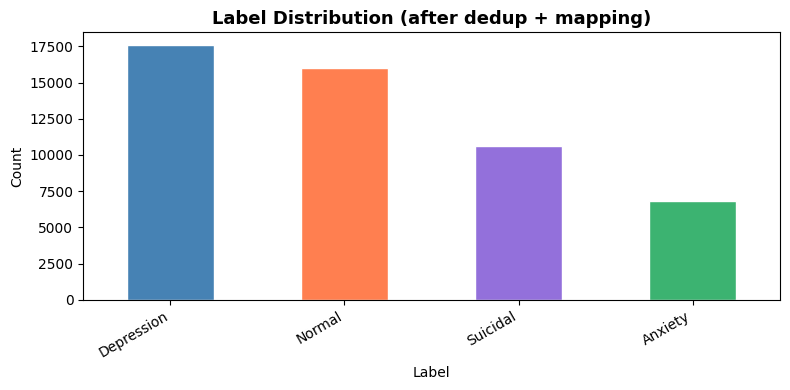

In [5]:
TEXT_COL  = 'statement'
LABEL_COL = 'status'

# ── Step 1: Deduplicate BEFORE split ──────────────────────────────────────
before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
print(f"Rows before dedup : {before:,}")
print(f"Rows after dedup  : {len(df):,}")
print(f"Duplicates removed: {before - len(df):,}")
print()

# ── Step 2: Label mapping — Suicidal is its own class ─────────────────────
# Bipolar is merged with Depression (overlapping symptoms, enough samples).
# Personality disorder is merged with Anxiety (overlapping symptoms).
# Suicidal is KEPT SEPARATE — must never be silently folded into another class.
LABEL_MAP = {
    'Depression':           'Depression',
    'depression':           'Depression',
    'Bipolar':              'Depression',
    'bipolar':              'Depression',

    'Suicidal':             'Suicidal',
    'suicidal':             'Suicidal',

    'Anxiety':              'Anxiety',
    'anxiety':              'Anxiety',
    'Stress':               'Anxiety',
    'stress':               'Anxiety',
    'Personality disorder': 'Anxiety',
    'personality disorder': 'Anxiety',

    'Normal':               'Normal',
    'normal':               'Normal',
}

print("Unique raw labels found:")
print(df[LABEL_COL].unique())
print()

df['label'] = df[LABEL_COL].map(LABEL_MAP)

unmapped = df['label'].isna().sum()
if unmapped > 0:
    print(f"WARNING: {unmapped} rows have unmapped labels and will be dropped.")
    print("Unmapped values:", df[df['label'].isna()][LABEL_COL].unique())
    df = df.dropna(subset=['label']).reset_index(drop=True)

print("Final label distribution:")
print(df['label'].value_counts())
print(f"\nTotal usable samples: {len(df):,}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar', ax=ax, color=['steelblue','coral','mediumpurple','mediumseagreen'],
                                 edgecolor='white')
ax.set_title('Label Distribution (after dedup + mapping)', fontsize=13, fontweight='bold')
ax.set_xlabel('Label')
ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()


## Cell 5 — Text Cleaning

In [6]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+', '', text)   # remove URLs
    text = re.sub(r'\s+', ' ', text).strip()       # collapse whitespace
    # Note: we do NOT remove punctuation/numbers here.
    # MentalRoBERTa's tokenizer handles subwords — stripping chars hurts it.
    return text

df['clean_text'] = df[TEXT_COL].apply(clean_text)
df = df[df['clean_text'].str.len() > 5].reset_index(drop=True)

print(f"Samples after cleaning: {len(df):,}")
print("\nSample cleaned texts:")
for i in range(3):
    print(f"  Original : {str(df[TEXT_COL].iloc[i])[:90]}")
    print(f"  Cleaned  : {df['clean_text'].iloc[i][:90]}")
    print()


Samples after cleaning: 51,013

Sample cleaned texts:
  Original : oh my gosh
  Cleaned  : oh my gosh

  Original : trouble sleeping, confused mind, restless heart. All out of tune
  Cleaned  : trouble sleeping, confused mind, restless heart. All out of tune

  Original : All wrong, back off dear, forward doubt. Stay in a restless and restless place
  Cleaned  : All wrong, back off dear, forward doubt. Stay in a restless and restless place



## Cell 6 — Binary Labels & Train/Val/Test Split

In [7]:
# Three independent binary labels — each is a separate classification task
df['depression_label'] = (df['label'] == 'Depression').astype(int)
df['anxiety_label']    = (df['label'] == 'Anxiety').astype(int)
df['suicidal_label']   = (df['label'] == 'Suicidal').astype(int)

print("Depression label distribution:")
print(df['depression_label'].value_counts())
print("\nAnxiety label distribution:")
print(df['anxiety_label'].value_counts())
print("\nSuicidal label distribution:")
print(df['suicidal_label'].value_counts())

X     = df['clean_text'].values
y_dep = df['depression_label'].values
y_anx = df['anxiety_label'].values
y_sui = df['suicidal_label'].values

# Stratify on combined label (0=Normal, 1=Anxiety, 2=Depression, 3=Suicidal)
# Each sample belongs to exactly one class so values are always 0-3
y_combined = (df['label'].map({'Normal':0,'Anxiety':1,'Depression':2,'Suicidal':3})).values

# 70% train, 15% val, 15% test
X_train, X_temp, yd_train, yd_temp, ya_train, ya_temp, ys_train, ys_temp, yc_train, yc_temp = \
    train_test_split(X, y_dep, y_anx, y_sui, y_combined,
                     test_size=0.30, random_state=SEED, stratify=y_combined)

X_val, X_test, yd_val, yd_test, ya_val, ya_test, ys_val, ys_test = \
    train_test_split(X_temp, yd_temp, ya_temp, ys_temp,
                     test_size=0.50, random_state=SEED, stratify=yc_temp)

print(f"\nSplit sizes:")
print(f"  Train      : {len(X_train):,}")
print(f"  Validation : {len(X_val):,}")
print(f"  Test       : {len(X_test):,}")


Depression label distribution:
depression_label
0    33426
1    17587
Name: count, dtype: int64

Anxiety label distribution:
anxiety_label
0    44208
1     6805
Name: count, dtype: int64

Suicidal label distribution:
suicidal_label
0    40373
1    10640
Name: count, dtype: int64

Split sizes:
  Train      : 35,709
  Validation : 7,652
  Test       : 7,652


## Cell 7 — Load MentalRoBERTa Tokenizer

In [8]:
MODEL_NAME = 'mental/mental-roberta-base'
MAX_LEN    = 128   # RoBERTa supports up to 512; 128 covers most Reddit posts

print(f"Loading tokenizer from: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=os.environ.get('HF_TOKEN'))
print(f"✓ Tokenizer loaded — vocab size: {tokenizer.vocab_size:,}")

# Verify tokenization
sample = "I feel completely hopeless and empty. I can't sleep."
encoded = tokenizer(sample, max_length=MAX_LEN, truncation=True)
print(f"\nSample encoding:")
print(f"  Text   : {sample}")
print(f"  Tokens : {len(encoded['input_ids'])} tokens")
print(f"  IDs    : {encoded['input_ids']}")


Loading tokenizer from: mental/mental-roberta-base


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/327 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

✓ Tokenizer loaded — vocab size: 50,265

Sample encoding:
  Text   : I feel completely hopeless and empty. I can't sleep.
  Tokens : 14 tokens
  IDs    : [0, 100, 619, 2198, 24418, 8, 5802, 4, 38, 64, 75, 3581, 4, 2]


## Cell 8 — PyTorch Dataset & DataLoader

In [9]:
class MentalHealthDataset(Dataset):
    def __init__(self, texts, dep_labels, anx_labels, sui_labels, tokenizer, max_len):
        self.texts      = texts
        self.dep_labels = dep_labels
        self.anx_labels = anx_labels
        self.sui_labels = sui_labels
        self.tokenizer  = tokenizer
        self.max_len    = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt',
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'dep_label':      torch.tensor(self.dep_labels[idx], dtype=torch.float),
            'anx_label':      torch.tensor(self.anx_labels[idx], dtype=torch.float),
            'sui_label':      torch.tensor(self.sui_labels[idx], dtype=torch.float),
        }


BATCH_SIZE = 32   # 32 is safe on T4 with MAX_LEN=128

train_dataset = MentalHealthDataset(X_train, yd_train, ya_train, ys_train, tokenizer, MAX_LEN)
val_dataset   = MentalHealthDataset(X_val,   yd_val,   ya_val,   ys_val,   tokenizer, MAX_LEN)
test_dataset  = MentalHealthDataset(X_test,  yd_test,  ya_test,  ys_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")


Train batches : 1116
Val batches   : 240
Test batches  : 240


## Cell 9 — Define the Model (MentalRoBERTa + 3 Classification Heads)

In [10]:
class MentalHealthClassifier(nn.Module):
    """
    MentalRoBERTa backbone with three independent binary classification heads:
    - depression_head : detects depressive language
    - anxiety_head    : detects anxiety-related language
    - suicidal_head   : detects suicidal ideation (kept SEPARATE for safety)

    Each head outputs a raw logit. Apply sigmoid to get a probability.
    """
    def __init__(self, model_name: str, hidden_dropout: float = 0.3):
        super().__init__()

        self.roberta = AutoModel.from_pretrained(
            model_name,
            token=os.environ.get('HF_TOKEN')
        )
        hidden_size = self.roberta.config.hidden_size  # 768 for roberta-base

        # Shared dropout on the [CLS] pooled representation
        self.dropout = nn.Dropout(hidden_dropout)

        # Three independent binary heads
        # Each: 768 → 256 → 1
        def make_head():
            return nn.Sequential(
                nn.Linear(hidden_size, 256),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(256, 1),
            )

        self.depression_head = make_head()
        self.anxiety_head    = make_head()
        self.suicidal_head   = make_head()

        # Initialize classification head weights
        for head in [self.depression_head, self.anxiety_head, self.suicidal_head]:
            for module in head.modules():
                if isinstance(module, nn.Linear):
                    nn.init.xavier_uniform_(module.weight)
                    nn.init.zeros_(module.bias)

    def forward(self, input_ids, attention_mask):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        # Use [CLS] token representation (first token)
        cls_output = outputs.last_hidden_state[:, 0, :]
        cls_output = self.dropout(cls_output)

        dep_logit = self.depression_head(cls_output).squeeze(1)
        anx_logit = self.anxiety_head(cls_output).squeeze(1)
        sui_logit = self.suicidal_head(cls_output).squeeze(1)

        return dep_logit, anx_logit, sui_logit


print(f"Loading backbone from: {MODEL_NAME}")
model = MentalHealthClassifier(MODEL_NAME).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


Loading backbone from: mental/mental-roberta-base


config.json:   0%|          | 0.00/682 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters     : 125,236,995
Trainable parameters : 125,236,995


## Cell 10 — Training Setup (Loss, Optimizer, Scheduler)

In [11]:
# ── Compute pos_weights from TRAINING labels only ─────────────────────────
def compute_pos_weight(labels):
    n_neg = (labels == 0).sum()
    n_pos = (labels == 1).sum()
    return torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float).to(DEVICE)

pos_weight_dep = compute_pos_weight(yd_train)
pos_weight_anx = compute_pos_weight(ya_train)
pos_weight_sui = compute_pos_weight(ys_train)

criterion_dep = nn.BCEWithLogitsLoss(pos_weight=pos_weight_dep)
criterion_anx = nn.BCEWithLogitsLoss(pos_weight=pos_weight_anx)
criterion_sui = nn.BCEWithLogitsLoss(pos_weight=pos_weight_sui)

# ── AdamW with no weight decay on bias/LayerNorm ──────────────────────────
# (standard practice for fine-tuning BERT-based models)
no_decay = ['bias', 'LayerNorm.weight', 'LayerNorm.bias']
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': 1e-2,
    },
    {
        'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0,
    },
]
optimizer = AdamW(optimizer_grouped_parameters, lr=2e-5, eps=1e-8)

# ── Linear warmup scheduler ───────────────────────────────────────────────
NUM_EPOCHS    = 5
EARLY_STOP    = 3   # BERT converges fast; patience of 3 is enough
total_steps   = len(train_loader) * NUM_EPOCHS
warmup_steps  = int(0.1 * total_steps)   # 10% warmup

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps  = warmup_steps,
    num_training_steps= total_steps,
)

print(f"Epochs              : {NUM_EPOCHS}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Total steps         : {total_steps:,}")
print(f"Warmup steps        : {warmup_steps:,}")
print(f"Early stopping      : {EARLY_STOP} epochs patience")
print(f"Initial LR          : 2e-5")
print(f"pos_weight_dep      : {pos_weight_dep.item():.3f}")
print(f"pos_weight_anx      : {pos_weight_anx.item():.3f}")
print(f"pos_weight_sui      : {pos_weight_sui.item():.3f}")


Epochs              : 5
Batch size          : 32
Total steps         : 5,580
Warmup steps        : 558
Early stopping      : 3 epochs patience
Initial LR          : 2e-5
pos_weight_dep      : 1.901
pos_weight_anx      : 6.497
pos_weight_sui      : 3.794


## Cell 11 — Training Loop

In [12]:
def train_one_epoch(model, loader, optimizer, scheduler, criteria, device):
    model.train()
    criterion_dep, criterion_anx, criterion_sui = criteria
    total_loss = 0.0
    dep_correct, anx_correct, sui_correct, total = 0, 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        dep_labels     = batch['dep_label'].to(device)
        anx_labels     = batch['anx_label'].to(device)
        sui_labels     = batch['sui_label'].to(device)

        optimizer.zero_grad()
        dep_pred, anx_pred, sui_pred = model(input_ids, attention_mask)

        loss_dep = criterion_dep(dep_pred, dep_labels)
        loss_anx = criterion_anx(anx_pred, anx_labels)
        loss_sui = criterion_sui(sui_pred, sui_labels)
        # Equal weighting across the three tasks
        loss = loss_dep + loss_anx + loss_sui

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss  += loss.item()
        dep_correct += ((dep_pred > 0).bool() == dep_labels.bool()).sum().item()
        anx_correct += ((anx_pred > 0).bool() == anx_labels.bool()).sum().item()
        sui_correct += ((sui_pred > 0).bool() == sui_labels.bool()).sum().item()
        total       += len(input_ids)

    n = len(loader)
    return total_loss/n, dep_correct/total, anx_correct/total, sui_correct/total


def evaluate(model, loader, criteria, device):
    model.eval()
    criterion_dep, criterion_anx, criterion_sui = criteria
    total_loss = 0.0
    dep_correct, anx_correct, sui_correct, total = 0, 0, 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            dep_labels     = batch['dep_label'].to(device)
            anx_labels     = batch['anx_label'].to(device)
            sui_labels     = batch['sui_label'].to(device)

            dep_pred, anx_pred, sui_pred = model(input_ids, attention_mask)

            loss_dep = criterion_dep(dep_pred, dep_labels)
            loss_anx = criterion_anx(anx_pred, anx_labels)
            loss_sui = criterion_sui(sui_pred, sui_labels)
            loss     = loss_dep + loss_anx + loss_sui

            total_loss  += loss.item()
            dep_correct += ((dep_pred > 0).bool() == dep_labels.bool()).sum().item()
            anx_correct += ((anx_pred > 0).bool() == anx_labels.bool()).sum().item()
            sui_correct += ((sui_pred > 0).bool() == sui_labels.bool()).sum().item()
            total       += len(input_ids)

    n = len(loader)
    return total_loss/n, dep_correct/total, anx_correct/total, sui_correct/total


criteria = (criterion_dep, criterion_anx, criterion_sui)

history = {
    'train_loss': [], 'val_loss': [],
    'train_dep_acc': [], 'train_anx_acc': [], 'train_sui_acc': [],
    'val_dep_acc':   [], 'val_anx_acc':   [], 'val_sui_acc':   [],
}

best_val_loss  = float('inf')
patience_count = 0

header = f"{'Epoch':>5} | {'TrLoss':>7} | {'VaLoss':>7} | {'VaDep':>6} | {'VaAnx':>6} | {'VaSui':>6}"
print(header)
print("-" * len(header))

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_dep, tr_anx, tr_sui = train_one_epoch(
        model, train_loader, optimizer, scheduler, criteria, DEVICE)
    va_loss, va_dep, va_anx, va_sui = evaluate(
        model, val_loader, criteria, DEVICE)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_dep_acc'].append(tr_dep)
    history['train_anx_acc'].append(tr_anx)
    history['train_sui_acc'].append(tr_sui)
    history['val_dep_acc'].append(va_dep)
    history['val_anx_acc'].append(va_anx)
    history['val_sui_acc'].append(va_sui)

    print(f"{epoch:>5} | {tr_loss:>7.4f} | {va_loss:>7.4f} | {va_dep:>5.1%} | {va_anx:>5.1%} | {va_sui:>5.1%}")

    if va_loss < best_val_loss:
        best_val_loss  = va_loss
        patience_count = 0
        torch.save(model.state_dict(), 'mental_health_model.pt')
        print(f"         ✓ Best model saved (val_loss={va_loss:.4f})")
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


Epoch |  TrLoss |  VaLoss |  VaDep |  VaAnx |  VaSui
----------------------------------------------------


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable huggingface/tokenizers: The current process just got forked, after

    1 |  1.7894 |  1.2141 | 83.8% | 95.1% | 83.0%
         ✓ Best model saved (val_loss=1.2141)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

    2 |  1.0724 |  1.1972 | 86.0% | 95.4% | 86.1%
         ✓ Best model saved (val_loss=1.1972)


...

    3 |  0.8419 |  1.3049 | 86.3% | 95.8% | 86.7%


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

    4 |  0.6425 |  1.5046 | 86.1% | 95.9% | 87.1%


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

    5 |  0.4924 |  1.7865 | 85.8% | 96.3% | 87.3%

Early stopping at epoch 5.

Training complete. Best val loss: 1.1972


## Cell 12 — Plot Training Curves

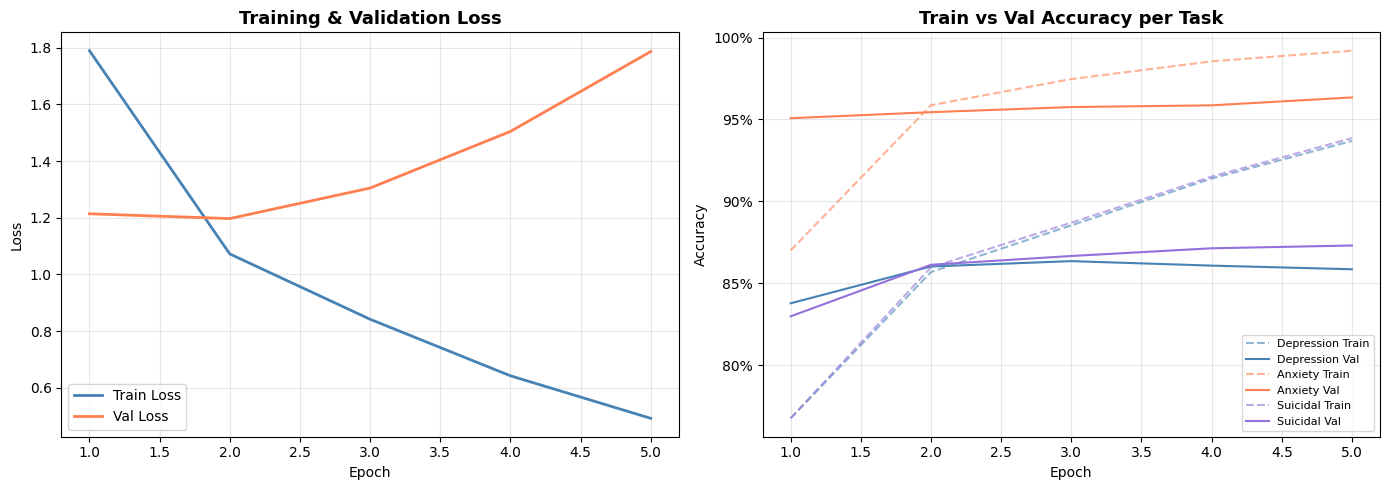


Final train loss : 0.4924
Final val loss   : 1.7865
Gap (val-train)  : +1.2940


In [13]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_ran, history['val_loss'],   label='Val Loss',   color='coral',     linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy — both train and val per task
for task, tr_key, va_key, color in [
    ('Depression', 'train_dep_acc', 'val_dep_acc', 'steelblue'),
    ('Anxiety',    'train_anx_acc', 'val_anx_acc', 'coral'),
    ('Suicidal',   'train_sui_acc', 'val_sui_acc', 'mediumpurple'),
]:
    axes[1].plot(epochs_ran, history[tr_key], linestyle='--', color=color, alpha=0.6, label=f'{task} Train')
    axes[1].plot(epochs_ran, history[va_key], linestyle='-',  color=color,             label=f'{task} Val')

axes[1].set_title('Train vs Val Accuracy per Task', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

# Overfitting summary — gap > 0.05 is the warning threshold
final_train = history['train_loss'][-1]
final_val   = history['val_loss'][-1]
gap         = final_val - final_train
print(f"\nFinal train loss : {final_train:.4f}")
print(f"Final val loss   : {final_val:.4f}")
print(f"Gap (val-train)  : {gap:+.4f}")
if gap > 0.10:
    print("WARNING: gap > 0.10 — overfitting. Consider more dropout or fewer epochs.")
elif gap < -0.05:
    print("WARNING: train > val — possible underfitting or unstable training.")
else:
    print("Gap looks healthy.")


## Cell 13 — Threshold Calibration on Validation Set

Instead of hardcoding 0.5, we find the threshold that maximises F1 per task on the **validation set**.  
The Suicidal head uses a lower threshold (higher sensitivity) — it's better to over-flag than miss.


In [14]:
model.load_state_dict(torch.load('mental_health_model.pt', map_location=DEVICE))
model.eval()

all_dep_probs, all_anx_probs, all_sui_probs = [], [], []
all_dep_true,  all_anx_true,  all_sui_true  = [], [], []

with torch.no_grad():
    for batch in val_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        dep_pred, anx_pred, sui_pred = model(input_ids, attention_mask)

        all_dep_probs.extend(torch.sigmoid(dep_pred).cpu().tolist())
        all_anx_probs.extend(torch.sigmoid(anx_pred).cpu().tolist())
        all_sui_probs.extend(torch.sigmoid(sui_pred).cpu().tolist())
        all_dep_true.extend(batch['dep_label'].int().tolist())
        all_anx_true.extend(batch['anx_label'].int().tolist())
        all_sui_true.extend(batch['sui_label'].int().tolist())

all_dep_probs = np.array(all_dep_probs)
all_anx_probs = np.array(all_anx_probs)
all_sui_probs = np.array(all_sui_probs)
all_dep_true  = np.array(all_dep_true)
all_anx_true  = np.array(all_anx_true)
all_sui_true  = np.array(all_sui_true)

# ── Sweep thresholds ──────────────────────────────────────────────────────
# For Suicidal: sweep lower range (prefer sensitivity over specificity)
thresholds_std = np.arange(0.3, 0.8, 0.05)
thresholds_sui = np.arange(0.2, 0.6, 0.05)   # intentionally lower

def best_threshold(probs, true_labels, thresholds):
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = (probs >= t).astype(int)
        # f1_score can raise if no positives predicted — guard it
        if preds.sum() == 0:
            continue
        f1 = f1_score(true_labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t, best_f1

THRESH_DEP, f1_dep = best_threshold(all_dep_probs, all_dep_true, thresholds_std)
THRESH_ANX, f1_anx = best_threshold(all_anx_probs, all_anx_true, thresholds_std)
THRESH_SUI, f1_sui = best_threshold(all_sui_probs, all_sui_true, thresholds_sui)

print("Calibrated thresholds (chosen on validation set):")
print(f"  Depression threshold : {THRESH_DEP:.2f}  (val F1 = {f1_dep:.3f})")
print(f"  Anxiety    threshold : {THRESH_ANX:.2f}  (val F1 = {f1_anx:.3f})")
print(f"  Suicidal   threshold : {THRESH_SUI:.2f}  (val F1 = {f1_sui:.3f})  ← lower = higher sensitivity")

# Save thresholds for ONNX inference helper
THRESHOLDS = {
    'depression': float(THRESH_DEP),
    'anxiety':    float(THRESH_ANX),
    'suicidal':   float(THRESH_SUI),
}
with open('thresholds.json', 'w') as f:
    json.dump(THRESHOLDS, f, indent=2)
print("\nThresholds saved to thresholds.json")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Calibrated thresholds (chosen on validation set):
  Depression threshold : 0.50  (val F1 = 0.807)
  Anxiety    threshold : 0.70  (val F1 = 0.858)
  Suicidal   threshold : 0.55  (val F1 = 0.738)  ← lower = higher sensitivity

Thresholds saved to thresholds.json


## Cell 14 — Evaluate on Test Set

In [15]:
model.load_state_dict(torch.load('mental_health_model.pt', map_location=DEVICE))
model.eval()

all_dep_preds, all_anx_preds, all_sui_preds = [], [], []
all_dep_probs, all_anx_probs, all_sui_probs = [], [], []
all_dep_true,  all_anx_true,  all_sui_true  = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        dep_pred, anx_pred, sui_pred = model(input_ids, attention_mask)

        dep_prob = torch.sigmoid(dep_pred).cpu().numpy()
        anx_prob = torch.sigmoid(anx_pred).cpu().numpy()
        sui_prob = torch.sigmoid(sui_pred).cpu().numpy()

        all_dep_probs.extend(dep_prob.tolist())
        all_anx_probs.extend(anx_prob.tolist())
        all_sui_probs.extend(sui_prob.tolist())

        all_dep_preds.extend((dep_prob >= THRESH_DEP).astype(int).tolist())
        all_anx_preds.extend((anx_prob >= THRESH_ANX).astype(int).tolist())
        all_sui_preds.extend((sui_prob >= THRESH_SUI).astype(int).tolist())

        all_dep_true.extend(batch['dep_label'].int().tolist())
        all_anx_true.extend(batch['anx_label'].int().tolist())
        all_sui_true.extend(batch['sui_label'].int().tolist())

# ── Print full reports ─────────────────────────────────────────────────────
for name, true, preds, probs in [
    ('DEPRESSION', all_dep_true, all_dep_preds, all_dep_probs),
    ('ANXIETY',    all_anx_true, all_anx_preds, all_anx_probs),
    ('SUICIDAL',   all_sui_true, all_sui_preds, all_sui_probs),
]:
    print("=" * 52)
    print(f"{name} DETECTION — Test Set")
    print("=" * 52)
    labels = [f'Not {name.capitalize()}', name.capitalize()]
    print(classification_report(true, preds, target_names=labels, zero_division=0))

    acc   = accuracy_score(true, preds)
    f1    = f1_score(true, preds, zero_division=0)
    # roc_auc and pr_auc require at least one positive sample
    try:
        auc   = roc_auc_score(true, probs)
        prauc = average_precision_score(true, probs)
    except ValueError:
        auc, prauc = float('nan'), float('nan')

    print(f"Accuracy: {acc:.1%}  F1: {f1:.3f}  ROC-AUC: {auc:.3f}  PR-AUC: {prauc:.3f}")
    print()


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


DEPRESSION DETECTION — Test Set
                precision    recall  f1-score   support

Not Depression       0.92      0.87      0.90      5014
    Depression       0.78      0.86      0.82      2638

      accuracy                           0.87      7652
     macro avg       0.85      0.87      0.86      7652
  weighted avg       0.87      0.87      0.87      7652

Accuracy: 86.9%  F1: 0.820  ROC-AUC: 0.944  PR-AUC: 0.906

ANXIETY DETECTION — Test Set
              precision    recall  f1-score   support

 Not Anxiety       0.99      0.96      0.98      6631
     Anxiety       0.80      0.93      0.86      1021

    accuracy                           0.96      7652
   macro avg       0.89      0.95      0.92      7652
weighted avg       0.96      0.96      0.96      7652

Accuracy: 95.9%  F1: 0.858  ROC-AUC: 0.989  PR-AUC: 0.939

SUICIDAL DETECTION — Test Set
              precision    recall  f1-score   support

Not Suicidal       0.96      0.87      0.92      6056
    Suicidal    

## Cell 15 — Confusion Matrices

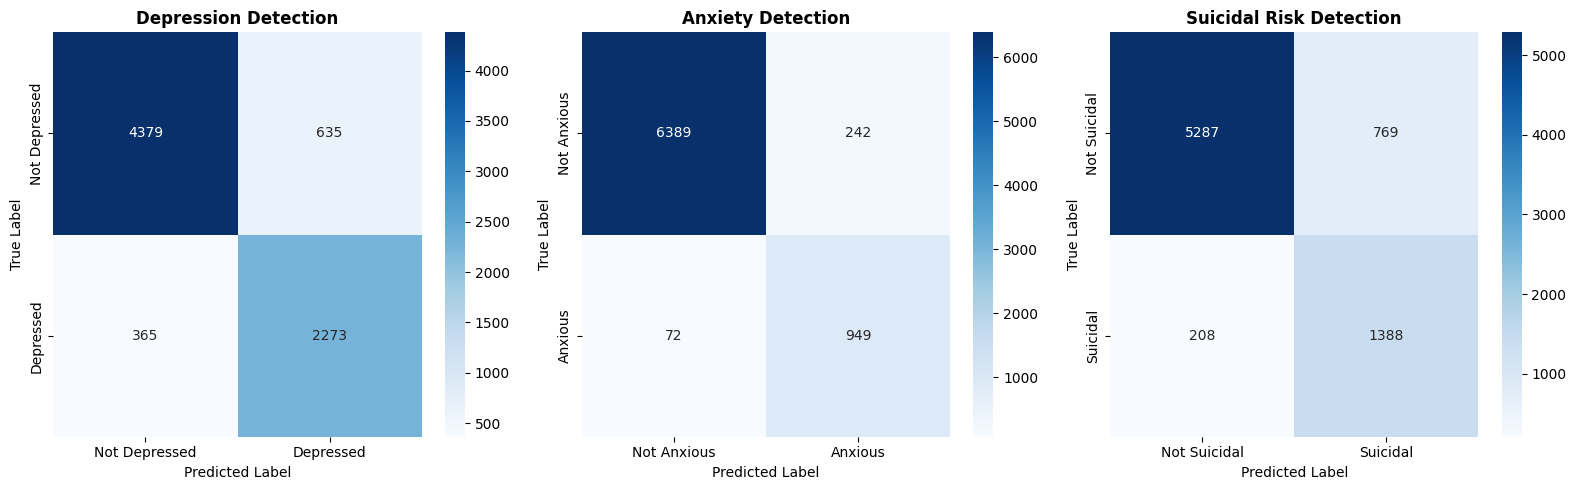

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, true, pred, title, labels in [
    (axes[0], all_dep_true, all_dep_preds, 'Depression Detection',
     ['Not Depressed', 'Depressed']),
    (axes[1], all_anx_true, all_anx_preds, 'Anxiety Detection',
     ['Not Anxious', 'Anxious']),
    (axes[2], all_sui_true, all_sui_preds, 'Suicidal Risk Detection',
     ['Not Suicidal', 'Suicidal']),
]:
    cm = confusion_matrix(true, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()


## Cell 16 — Export to ONNX

In [17]:
model.load_state_dict(torch.load('mental_health_model.pt', map_location='cpu'))
model.eval()
model.to('cpu')

# Dummy inputs for tracing (batch_size=1, seq_len=MAX_LEN)
dummy_input_ids      = torch.ones(1, MAX_LEN, dtype=torch.long)
dummy_attention_mask = torch.ones(1, MAX_LEN, dtype=torch.long)

torch.onnx.export(
    model,
    (dummy_input_ids, dummy_attention_mask),
    'mental_health_model.onnx',
    input_names   = ['input_ids', 'attention_mask'],
    output_names  = ['depression', 'anxiety', 'suicidal'],
    opset_version = 14,
    dynamic_axes  = {
        'input_ids':      {0: 'batch_size'},
        'attention_mask': {0: 'batch_size'},
        'depression':     {0: 'batch_size'},
        'anxiety':        {0: 'batch_size'},
        'suicidal':       {0: 'batch_size'},
    },
)

# Validate
onnx_model = onnx.load('mental_health_model.onnx')
onnx.checker.check_model(onnx_model)
print("✓ ONNX model is valid.")

# Quick inference test
session   = ort.InferenceSession('mental_health_model.onnx')
outputs   = session.run(None, {
    'input_ids':      dummy_input_ids.numpy(),
    'attention_mask': dummy_attention_mask.numpy(),
})
print(f"Test output — depression: {outputs[0][0]:.4f}, anxiety: {outputs[1][0]:.4f}, suicidal: {outputs[2][0]:.4f}")
print("✓ ONNX inference successful.")

# Save tokenizer config for the inference helper
tokenizer.save_pretrained('mental_health_tokenizer')
print("✓ Tokenizer saved to mental_health_tokenizer/")


/tmp/ipykernel_57/938528387.py:9: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0515 15:28:56.038000 57 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `MentalHealthClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `MentalHealthClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/exporter/_onnx_program.py:460: UserWarning: # The axis name: batch_size will not be used, since it shares the same shape constraints with another axis: batch_size.
  rename_mapping = _dynamic_shapes.create_rename_mapping(
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib

[torch.onnx] Translate the graph into ONNX... ✅
✓ ONNX model is valid.
Test output — depression: 4.0624, anxiety: -8.2262, suicidal: -2.8993
✓ ONNX inference successful.
✓ Tokenizer saved to mental_health_tokenizer/


## Cell 17 — Inference Helper with Crisis Override

**Safety design:**
1. Crisis keyword check runs FIRST — before any model inference.
2. If suicidal probability exceeds threshold → always return CRISIS regardless of other scores.
3. If confidence of all heads is low → return 'UNCERTAIN' instead of a wrong label.


In [18]:
import json

# Load thresholds calibrated in Cell 13
with open('thresholds.json') as f:
    THRESHOLDS = json.load(f)

# Hard-coded crisis keywords — these bypass the model entirely
CRISIS_KEYWORDS = [
    'kill myself', 'want to die', 'end my life', 'take my life',
    'suicide', 'suicidal', 'no reason to live', 'better off dead',
    "can't go on", 'cannot go on', 'life is not worth', 'end it all',
    'want to end', 'plan to die',
]

# Minimum confidence to show a label (below this → UNCERTAIN)
MIN_CONFIDENCE = 0.45

onnx_session = ort.InferenceSession('mental_health_model.onnx')

def predict(text: str, tokenizer, session, thresholds: dict) -> dict:
    """
    Returns:
        {
            'depression_prob': float,
            'anxiety_prob':    float,
            'suicidal_prob':   float,
            'risk_level':      'CRISIS' | 'HIGH' | 'MODERATE' | 'LOW' | 'UNCERTAIN',
            'flags':           list[str],   # which heads fired
            'crisis_override': bool,        # True if keyword-triggered
        }
    """
    text_lower = text.lower()

    # ── Safety check 1: hard-coded crisis keywords ─────────────────────────
    if any(kw in text_lower for kw in CRISIS_KEYWORDS):
        return {
            'depression_prob': None,
            'anxiety_prob':    None,
            'suicidal_prob':   None,
            'risk_level':      'CRISIS',
            'flags':           ['SUICIDAL'],
            'crisis_override': True,
            'message':         (
                "⚠️ Crisis detected. Please reach out for help immediately. "
                "If you are in Bangladesh: Kaan Pete Roi — 01779-554391. "
                "International: findahelpline.com"
            ),
        }

    # ── Model inference ────────────────────────────────────────────────────
    cleaned = re.sub(r'http\S+|www\S+', '', text)
    cleaned = re.sub(r'\s+', ' ', cleaned).strip()

    enc = tokenizer(
        cleaned,
        max_length     = MAX_LEN,
        padding        = 'max_length',
        truncation     = True,
        return_tensors = 'np',
    )

    dep_logit, anx_logit, sui_logit = session.run(None, {
        'input_ids':      enc['input_ids'].astype(np.int64),
        'attention_mask': enc['attention_mask'].astype(np.int64),
    })

    def sigmoid(x):
        return float(1 / (1 + np.exp(-x[0])))

    dep_prob = sigmoid(dep_logit)
    anx_prob = sigmoid(anx_logit)
    sui_prob = sigmoid(sui_logit)

    # ── Safety check 2: suicidal head above threshold ─────────────────────
    flags = []
    if sui_prob >= thresholds['suicidal']:
        flags.append('SUICIDAL')
    if dep_prob >= thresholds['depression']:
        flags.append('DEPRESSION')
    if anx_prob >= thresholds['anxiety']:
        flags.append('ANXIETY')

    # Risk level logic
    max_prob = max(dep_prob, anx_prob, sui_prob)

    if 'SUICIDAL' in flags:
        risk = 'CRISIS'
        message = (
            "⚠️ Suicidal ideation detected. Please seek help. "
            "Kaan Pete Roi (BD): 01779-554391 | findahelpline.com"
        )
    elif max_prob < MIN_CONFIDENCE:
        risk    = 'UNCERTAIN'
        message = "Not enough signal to classify. Please consult a professional."
    elif max_prob >= 0.75:
        risk    = 'HIGH'
        message = "High risk detected. Consider reaching out to a mental health professional."
    elif max_prob >= thresholds.get('depression', 0.5):
        risk    = 'MODERATE'
        message = "Moderate risk. Consider speaking to someone you trust."
    else:
        risk    = 'LOW'
        message = "Low risk detected."

    return {
        'depression_prob': round(dep_prob, 4),
        'anxiety_prob':    round(anx_prob, 4),
        'suicidal_prob':   round(sui_prob, 4),
        'risk_level':      risk,
        'flags':           flags,
        'crisis_override': False,
        'message':         message,
    }


# ── Test sentences ─────────────────────────────────────────────────────────
test_sentences = [
    "I feel completely hopeless and empty. I can't sleep and nothing makes me happy.",
    "I can't stop worrying. My heart is racing and I feel panicked all the time.",
    "I had a good day today. Work went well and I feel fine overall.",
    "I've been crying every day. I feel worthless and like a burden to my family.",
    "I'm terrified of everything. Even leaving the house makes me panic.",
    "I want to kill myself. I don't see any point in continuing.",  # should trigger CRISIS
    "I am not depressed, just a bit tired from work this week.",   # negation test
]

print(f"{'Text':<58} | {'Dep':>5} | {'Anx':>5} | {'Sui':>5} | {'Risk':<10}")
print("-" * 95)
for sent in test_sentences:
    result = predict(sent, tokenizer, onnx_session, THRESHOLDS)
    short  = sent[:55] + '...' if len(sent) > 58 else sent
    if result['crisis_override']:
        print(f"{short:<58} | {'N/A':>5} | {'N/A':>5} | {'N/A':>5} | {result['risk_level']:<10}  ← KEYWORD TRIGGERED")
    else:
        print(f"{short:<58} | {result['depression_prob']:>5.3f} | {result['anxiety_prob']:>5.3f} | {result['suicidal_prob']:>5.3f} | {result['risk_level']:<10}")


Text                                                       |   Dep |   Anx |   Sui | Risk      
-----------------------------------------------------------------------------------------------
I feel completely hopeless and empty. I can't sleep and... | 0.750 | 0.713 | 0.039 | HIGH      
I can't stop worrying. My heart is racing and I feel pa... | 0.004 | 0.998 | 0.002 | HIGH      
I had a good day today. Work went well and I feel fine ... | 0.237 | 0.017 | 0.021 | UNCERTAIN 
I've been crying every day. I feel worthless and like a... | 0.203 | 0.965 | 0.004 | HIGH      
I'm terrified of everything. Even leaving the house mak... | 0.005 | 0.997 | 0.002 | HIGH      
I want to kill myself. I don't see any point in continu... |   N/A |   N/A |   N/A | CRISIS      ← KEYWORD TRIGGERED
I am not depressed, just a bit tired from work this week.  | 0.979 | 0.001 | 0.102 | HIGH      


## Cell 18 — Verify Output Files

In [19]:
import os

files_to_download = [
    'mental_health_model.onnx',
    'mental_health_model.pt',
    'thresholds.json',
    'mental_health_tokenizer/tokenizer_config.json',
    'mental_health_tokenizer/vocab.json',
    'mental_health_tokenizer/merges.txt',
    'training_curves.png',
    'confusion_matrices.png',
    'label_distribution.png',
]

print("Output files:")
print("=" * 52)
for f in files_to_download:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  ✓  {f:<45} ({size:.1f} KB)")
    else:
        print(f"  ✗  {f:<45} NOT FOUND")

print("\nDownload all from the Kaggle output panel (right sidebar → Output).")
print("You need: mental_health_model.onnx + thresholds.json + mental_health_tokenizer/")


Output files:
  ✓  mental_health_model.onnx                      (1123.7 KB)
  ✓  mental_health_model.pt                        (489294.5 KB)
  ✓  thresholds.json                               (0.1 KB)
  ✓  mental_health_tokenizer/tokenizer_config.json (1.2 KB)
  ✓  mental_health_tokenizer/vocab.json            (779.6 KB)
  ✓  mental_health_tokenizer/merges.txt            (445.6 KB)
  ✓  training_curves.png                           (127.0 KB)
  ✓  confusion_matrices.png                        (98.3 KB)
  ✓  label_distribution.png                        (42.6 KB)

Download all from the Kaggle output panel (right sidebar → Output).
You need: mental_health_model.onnx + thresholds.json + mental_health_tokenizer/


In [20]:
# McNemar's Test — Compare Full Model vs Baselines per Head
from scipy.stats import chi2

def mcnemar_test(y_true, preds_a, preds_b, label=""):
    """
    McNemar's test with continuity correction.
    preds_a = full model, preds_b = baseline
    """
    y_true  = np.array(y_true)
    preds_a = np.array(preds_a)
    preds_b = np.array(preds_b)

    # Discordant pairs
    b = np.sum((preds_a == y_true) & (preds_b != y_true))  # A correct, B wrong
    c = np.sum((preds_a != y_true) & (preds_b == y_true))  # A wrong, B correct

    # With continuity correction
    chi2_stat = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0.0
    p_value   = 1 - chi2.cdf(chi2_stat, df=1)

    print(f"{label}")
    print(f"  b (Full correct, Baseline wrong) : {b}")
    print(f"  c (Full wrong, Baseline correct) : {c}")
    print(f"  chi2 (with continuity correction): {chi2_stat:.4f}")
    print(f"  p-value                          : {p_value:.6f}")
    print(f"  Significant (p<0.05)             : {p_value < 0.05}")
    print()
    return chi2_stat, p_value


# ── Baseline 1: No pos_weight (all weights = 1.0) ─────────────────────────
# Retrain quickly for 2 epochs with no pos_weight
print("Training Baseline 1: No pos_weight...")
model_b1 = MentalHealthClassifier(MODEL_NAME).to(DEVICE)

criterion_b1_dep = nn.BCEWithLogitsLoss()
criterion_b1_anx = nn.BCEWithLogitsLoss()
criterion_b1_sui = nn.BCEWithLogitsLoss()
criteria_b1 = (criterion_b1_dep, criterion_b1_anx, criterion_b1_sui)

opt_b1 = AdamW(model_b1.parameters(), lr=2e-5, eps=1e-8)
sch_b1 = get_linear_schedule_with_warmup(opt_b1, num_warmup_steps=558, num_training_steps=5580)

for ep in range(2):
    train_one_epoch(model_b1, train_loader, opt_b1, sch_b1, criteria_b1, DEVICE)
    print(f"  Epoch {ep+1} done")

model_b1.eval()
b1_dep_preds, b1_anx_preds, b1_sui_preds = [], [], []
b1_dep_probs, b1_anx_probs, b1_sui_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        dep_pred, anx_pred, sui_pred = model_b1(input_ids, attention_mask)
        dep_prob = torch.sigmoid(dep_pred).cpu().numpy()
        anx_prob = torch.sigmoid(anx_pred).cpu().numpy()
        sui_prob = torch.sigmoid(sui_pred).cpu().numpy()
        b1_dep_probs.extend(dep_prob.tolist())
        b1_anx_probs.extend(anx_prob.tolist())
        b1_sui_probs.extend(sui_prob.tolist())
        b1_dep_preds.extend((dep_prob >= 0.50).astype(int).tolist())
        b1_anx_preds.extend((anx_prob >= 0.50).astype(int).tolist())
        b1_sui_preds.extend((sui_prob >= 0.50).astype(int).tolist())

print(f"Baseline 1 (No pos_weight) — Depression  F1: {f1_score(all_dep_true, b1_dep_preds):.3f}  ROC-AUC: {roc_auc_score(all_dep_true, b1_dep_probs):.3f}")
print(f"Baseline 1 (No pos_weight) — Anxiety     F1: {f1_score(all_anx_true, b1_anx_preds):.3f}  ROC-AUC: {roc_auc_score(all_anx_true, b1_anx_probs):.3f}")
print(f"Baseline 1 (No pos_weight) — Suicidal    F1: {f1_score(all_sui_true, b1_sui_preds):.3f}  ROC-AUC: {roc_auc_score(all_sui_true, b1_sui_probs):.3f}")
print()

# ── Baseline 2: Fixed threshold τ=0.50 for all heads ─────────────────────
# Use full model predictions already computed — just change threshold
b2_dep_preds = (np.array(all_dep_probs) >= 0.50).astype(int).tolist()
b2_anx_preds = (np.array(all_anx_probs) >= 0.50).astype(int).tolist()
b2_sui_preds = (np.array(all_sui_probs) >= 0.50).astype(int).tolist()

print(f"Baseline 2 (Fixed τ=0.50) — Depression  F1: {f1_score(all_dep_true, b2_dep_preds):.3f}")
print(f"Baseline 2 (Fixed τ=0.50) — Anxiety     F1: {f1_score(all_anx_true, b2_anx_preds):.3f}")
print(f"Baseline 2 (Fixed τ=0.50) — Suicidal    F1: {f1_score(all_sui_true, b2_sui_preds):.3f}")
print()

# ── Baseline 3: Shared single head ────────────────────────────────────────
class MentalHealthClassifierShared(nn.Module):
    """Single shared head predicting all 3 tasks (no independence)."""
    def __init__(self, model_name):
        super().__init__()
        self.roberta = AutoModel.from_pretrained(model_name, token=os.environ.get('HF_TOKEN'))
        hidden_size  = self.roberta.config.hidden_size
        self.dropout = nn.Dropout(0.3)
        self.shared_head = nn.Sequential(
            nn.Linear(hidden_size, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 3),   # 3 outputs from single head
        )

    def forward(self, input_ids, attention_mask):
        outputs    = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = self.dropout(outputs.last_hidden_state[:, 0, :])
        out        = self.shared_head(cls_output)
        return out[:, 0], out[:, 1], out[:, 2]

print("Training Baseline 3: Shared single head...")
model_b3   = MentalHealthClassifierShared(MODEL_NAME).to(DEVICE)
criteria_b3 = (criterion_dep, criterion_anx, criterion_sui)
opt_b3      = AdamW(model_b3.parameters(), lr=2e-5, eps=1e-8)
sch_b3      = get_linear_schedule_with_warmup(opt_b3, num_warmup_steps=558, num_training_steps=5580)

for ep in range(2):
    train_one_epoch(model_b3, train_loader, opt_b3, sch_b3, criteria_b3, DEVICE)
    print(f"  Epoch {ep+1} done")

model_b3.eval()
b3_dep_preds, b3_anx_preds, b3_sui_preds = [], [], []
b3_dep_probs, b3_anx_probs, b3_sui_probs = [], [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        dep_pred, anx_pred, sui_pred = model_b3(input_ids, attention_mask)
        dep_prob = torch.sigmoid(dep_pred).cpu().numpy()
        anx_prob = torch.sigmoid(anx_pred).cpu().numpy()
        sui_prob = torch.sigmoid(sui_pred).cpu().numpy()
        b3_dep_probs.extend(dep_prob.tolist())
        b3_anx_probs.extend(anx_prob.tolist())
        b3_sui_probs.extend(sui_prob.tolist())
        b3_dep_preds.extend((dep_prob >= 0.50).astype(int).tolist())
        b3_anx_preds.extend((anx_prob >= 0.50).astype(int).tolist())
        b3_sui_preds.extend((sui_prob >= 0.50).astype(int).tolist())

print(f"Baseline 3 (Shared Head)  — Depression  F1: {f1_score(all_dep_true, b3_dep_preds):.3f}  ROC-AUC: {roc_auc_score(all_dep_true, b3_dep_probs):.3f}")
print(f"Baseline 3 (Shared Head)  — Anxiety     F1: {f1_score(all_anx_true, b3_anx_preds):.3f}  ROC-AUC: {roc_auc_score(all_anx_true, b3_anx_probs):.3f}")
print(f"Baseline 3 (Shared Head)  — Suicidal    F1: {f1_score(all_sui_true, b3_sui_preds):.3f}  ROC-AUC: {roc_auc_score(all_sui_true, b3_sui_probs):.3f}")
print()

# ── McNemar's Tests ────────────────────────────────────────────────────────
print("=" * 60)
print("McNemar's Test Results (Full Model vs Each Baseline)")
print("=" * 60)
print()

for head_name, full_p, full_true, b1_p, b2_p, b3_p in [
    ("DEPRESSION", all_dep_preds, all_dep_true, b1_dep_preds, b2_dep_preds, b3_dep_preds),
    ("ANXIETY",    all_anx_preds, all_anx_true, b1_anx_preds, b2_anx_preds, b3_anx_preds),
    ("SUICIDAL",   all_sui_preds, all_sui_true, b1_sui_preds, b2_sui_preds, b3_sui_preds),
]:
    print(f"── {head_name} HEAD ──")
    mcnemar_test(full_true, full_p, b1_p, f"Full vs Baseline-1 (No pos_weight)")
    mcnemar_test(full_true, full_p, b2_p, f"Full vs Baseline-2 (Fixed τ=0.50)")
    mcnemar_test(full_true, full_p, b3_p, f"Full vs Baseline-3 (Shared Head)")

Training Baseline 1: No pos_weight...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of RobertaModel were not initialized from the model checkpoint at mental/mental-roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has alrea

  Epoch 1 done


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Epoch 2 done


...

  Epoch 1 done


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Epoch 2 done


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Baseline 3 (Shared Head)  — Depression  F1: 0.801  ROC-AUC: 0.940
Baseline 3 (Shared Head)  — Anxiety     F1: 0.859  ROC-AUC: 0.989
Baseline 3 (Shared Head)  — Suicidal    F1: 0.709  ROC-AUC: 0.945

McNemar's Test Results (Full Model vs Each Baseline)

── DEPRESSION HEAD ──
Full vs Baseline-1 (No pos_weight)
  b (Full correct, Baseline wrong) : 424
  c (Full wrong, Baseline correct) : 377
  chi2 (with continuity correction): 2.6417
  p-value                          : 0.104092
  Significant (p<0.05)             : False

Full vs Baseline-2 (Fixed τ=0.50)
  b (Full correct, Baseline wrong) : 0
  c (Full wrong, Baseline correct) : 0
  chi2 (with continuity correction): 0.0000
  p-value                          : 1.000000
  Significant (p<0.05)             : False

Full vs Baseline-3 (Shared Head)
  b (Full correct, Baseline wrong) : 354
  c (Full wrong, Baseline correct) : 182
  chi2 (with continuity correction): 54.5541
  p-value                          : 0.000000
  Significant (p<0.05)